## Annotation Analysis

Two annotators annotated part 3 of the dataset. We use Cohen's Kappa to compute the agreement between these two annotators. 

In [27]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import cohen_kappa_score
from augment_sheet import merge_excel_files, sheets_to_dataframe

# annotated data directory path
annotated_data_dir = Path('annotated_data')

# match the name of files in the directory with pattern 'part_[0-9].xlsx' using re
file_pattern = re.compile(r'.*part_[0-9]+\.xlsx')
files = [annotated_data_dir / f for f in os.listdir(annotated_data_dir) if file_pattern.match(f)]

# merge excel files
# merge_excel_files(files, 'mcmaster_reddit.xlsx')

# read all sheets from the merged excel file into a DataFrame
df_all = sheets_to_dataframe(annotated_data_dir / 'mcmaster_reddit.xlsx')

# read sheet named 'part_3_[AB]' under annotated_data_dir into DataFrame
df_part_3_A = pd.read_excel(annotated_data_dir / 'mcmaster_reddit_part_3_A.xlsx')
df_part_3_B = pd.read_excel(annotated_data_dir / 'mcmaster_reddit_part_3_B.xlsx')

# compute Cohen's kappa score for the two annotators on the 'part_3_A' sheet
ck_score = cohen_kappa_score(df_part_3_A['label'].values, df_part_3_B['label'].values)
print(f"Cohen's Kappa score: {ck_score:.4f}")


Cohen's Kappa score: 0.4265


Next, we determine the ground truth labels for the dataset through adjudication: we look at where the annotators for part 3 disagree and assign the groud truth label to our best understanding of the datapoints (posts). We also assign/validate labels to datapoints having invlaid labels (e.g.,missing values, labels in lower case, and ","). 

See files in the dirctory `annotated_data`:
- `mcmaster_reddit_part_[1-7].xlsx` are the data with ground truth labels and
- `mcmaster_reddit_part_3_[AB].xlsx` are data labeled by two annotators.


### Label Distribution Visualization

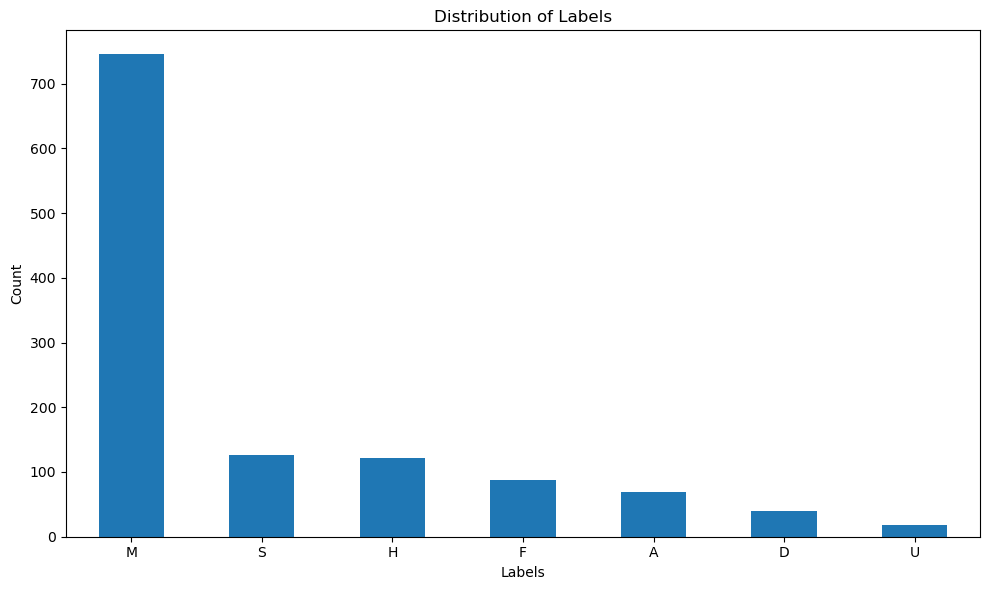

In [28]:
import matplotlib.pyplot as plt

# plot the distribution of labels in the merged DataFrame
plt.figure(figsize=(10, 6))
df_all['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Labels')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('label_distribution.png')
plt.show()

## Dataset Preparation

**Data Split**
- Train: 60%
- Validation: 20%
- Test: 20%

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

# Load data
data = pd.read_csv('annotated_data/dataset.csv')

# Drop the rows with missing labels
data = data.dropna(subset=['label'])

# Split into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.16, random_state=42
)


# Preprocess text with TF-IDF
vectorizer = TfidfVectorizer(max_features=10000)  # Limit to 10,000 features
vectorizer.fit(X_train_val)
X_train_tfidf = vectorizer.transform(X_train).toarray()
X_val_tfidf = vectorizer.transform(X_val).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

# Encode labels
le = LabelEncoder()
le.fit(y_train_val)
y_train_encoded = le.transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_tfidf, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_tfidf, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Models

### Simple Baseline

Simple baseline model by always predicting the class `M`.

In [ ]:
from collections import Counter
from sklearn.metrics import accuracy_score

class BaselineModel:
    def fit(self, X, y):
        # Find the most common label in the training data
        self.most_common_label = Counter(y).most_common(1)[0][0]
    
    def predict(self, X):
        # Return the most common label for each input text
        return [self.most_common_label] * len(X)

# Train the baseline model
baseline_model = BaselineModel()
baseline_model.fit(X_train, y_train)

# Evaluate the baseline model using accuracy
y_val_pred = baseline_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Baseline accuracy: {baseline_accuracy:.4f}')

Baseline accuracy: 0.6336


### Logistic Regression

The word2vec model is available here: http://vectors.nlpl.eu/repository/20/5.zip

In [39]:
import gensim
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Load Word2Vec model
model = gensim.models.KeyedVectors.load_word2vec_format('word2vec.bin', binary=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Vectorize text function
def vectorize_text(text):
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha() and word not in stop_words]
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)
    
# Vectorize text data
X_train_w2v = np.array([vectorize_text(text) for text in X_train])
X_val_w2v = np.array([vectorize_text(text) for text in X_val])
X_test_w2v = np.array([vectorize_text(text) for text in X_test])

# train model with sklearn logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train logistic regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_w2v, y_train)
y_pred = lr.predict(X_val_w2v)
accuracy = accuracy_score(y_val, y_pred)
print(f'Validation accuracy: {accuracy:.4f}')


Validation accuracy: 0.6336


In [31]:
from torch.amp import GradScaler, autocast

# Set up device for training (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the neural network
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Output logits
        return x

# Define function to evaluate model performance
def evaluate(model, data_loader, criterion):
    
    correct = 0
    total = 0
    losses = [] # loss per batch

    model.eval()
    with torch.no_grad():  # No gradient calculation for evaluation
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.shape[0]
            correct += int((predicted == labels).sum())
            losses.append(loss.item())

    accuracy = 100 * correct / total
    avg_loss = np.mean(losses)

    model.train()

    return accuracy, avg_loss

# Initialize GradScaler
scaler = GradScaler()

# Training loop
def training_loop(num_epochs, optimizer, model, criterion, train_loader, test_loader):
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    
    for epoch in range(num_epochs):

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            with autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # Evaluate on train and test sets after each epoch
        train_accuracy, train_loss = evaluate(model, train_loader, criterion)
        test_accuracy, test_loss = evaluate(model, test_loader, criterion)

        print(f'Epoch {epoch+1:02d}/{num_epochs:02d} - Train Loss: {train_loss:.6f}, Train Acc: {train_accuracy:.2f}%')
        print(f'            - Test Loss: {test_loss:.6f}, Test Acc: {test_accuracy:.2f}%')
        print("-" * 60)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        
    return train_losses, test_losses, train_accuracies, test_accuracies

# Prediction function for new texts
def predict_nn(model, vectorizer, le, texts):
    model.eval()
    with torch.no_grad():
        X_new = vectorizer.transform(texts).toarray()
        X_new_tensor = torch.tensor(X_new, dtype=torch.float32)
        outputs = model(X_new_tensor)
        _, predicted = torch.max(outputs, 1)
        predicted_labels = le.inverse_transform(predicted.numpy())
        return predicted_labels
    
import matplotlib.pyplot as plt

def plot_metrics(train_metrics, test_metrics, metric_name):
    plt.figure(figsize=(8, 6))
    epochs = np.arange(len(train_metrics))

    plt.plot(epochs, train_metrics, label=f'Train {metric_name}', color='blue')
    plt.plot(epochs, test_metrics, label=f'Validation {metric_name}', color='red')

    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Using device: cuda


Epoch 01/50 - Train Loss: 2.105794, Train Acc: 41.25%
            - Test Loss: 2.109540, Test Acc: 34.15%
------------------------------------------------------------
Epoch 02/50 - Train Loss: 1.956296, Train Acc: 59.62%
            - Test Loss: 1.966751, Test Acc: 60.00%
------------------------------------------------------------
Epoch 03/50 - Train Loss: 1.745090, Train Acc: 59.33%
            - Test Loss: 1.765614, Test Acc: 60.00%
------------------------------------------------------------
Epoch 04/50 - Train Loss: 1.514658, Train Acc: 59.33%
            - Test Loss: 1.549688, Test Acc: 60.00%
------------------------------------------------------------
Epoch 05/50 - Train Loss: 1.346184, Train Acc: 59.33%
            - Test Loss: 1.403150, Test Acc: 60.00%
------------------------------------------------------------
Epoch 06/50 - Train Loss: 1.230287, Train Acc: 59.33%
            - Test Loss: 1.331773, Test Acc: 60.00%
-----------------------------------------------------------

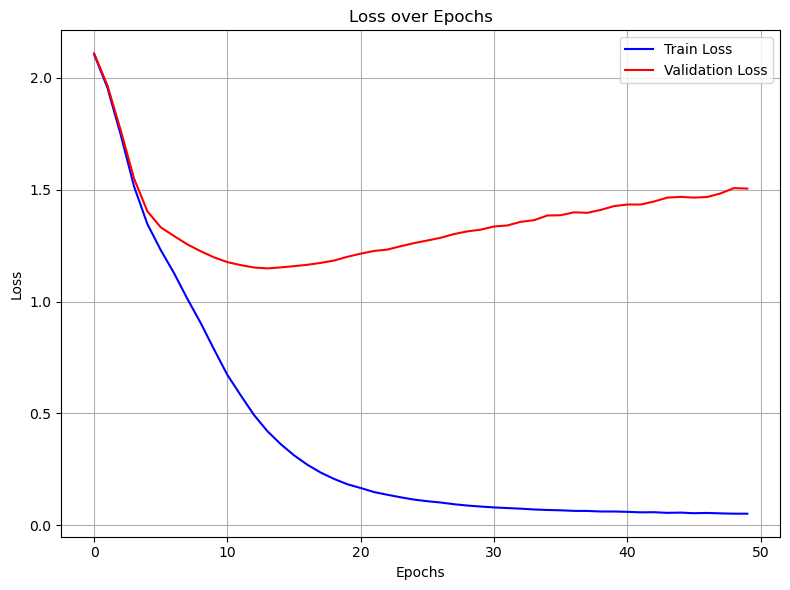

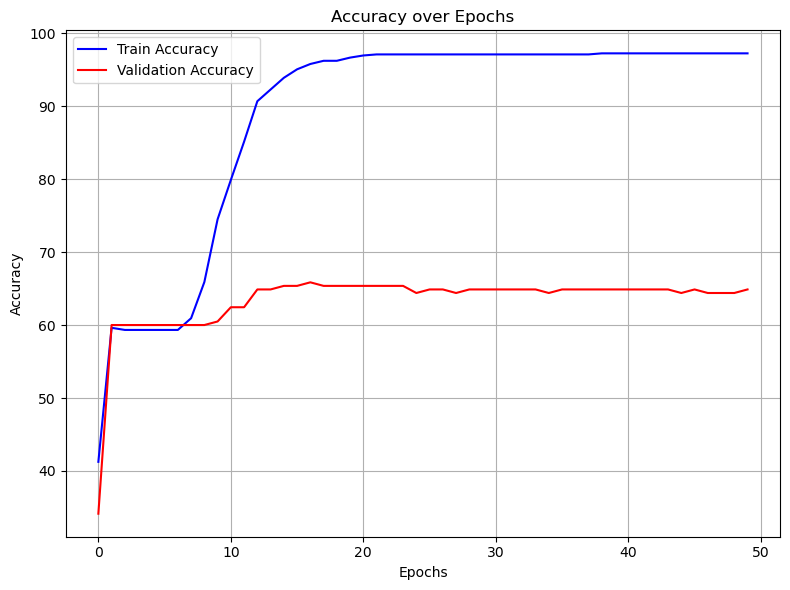

In [32]:

# Initialize the model
input_dim = X_train_tfidf.shape[1]  # Number of TF-IDF features
hidden_dim = 128
output_dim = len(le.classes_)  # Number of unique labels
model = FFNN(input_dim, hidden_dim, output_dim).to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50

# train model
train_losses, test_losses, train_accuracies, test_accuracies = training_loop(
    num_epochs, 
    optimizer, 
    model, 
    criterion, 
    train_loader, 
    test_loader)
# Plot loss
plot_metrics(train_losses, test_losses, 'Loss')
plot_metrics(train_accuracies, test_accuracies, 'Accuracy')
